In [1]:
################################################################################################################
### Set Energy Threshhold 
################################################################################################################

import numpy as np

# Take f_j ~ dJac(a,a) with a = ||j||_1^3
# Then E[f] = \sum_{j\in N^2} 1/(2||j||_1^3 + 3)
# Sum over m-1 multi-indices with ||j||_1 = m
# Then 
# E[f] = \sum_{m \in \N} (m-1)/(2m^3 + 3)
# Limit should be about 0.20872 by Wolfralm... lets check
terms = np.arange(2,10_000)
Sn = [0]
tol = 1e-8
for term in terms:
    dS = (term - 1) / (2*term**3 + 3)
    if dS < tol:
        print(f"Convergned in {term} steps to: {Sn[-1]}")
        break
    else: 
        Sn.append(Sn[-1] + dS)

# To obtain 95% energy, cannot just truncate at m, since we build up the product set in lexicographic order...
# Check that 95% energy is retained: 
max_univariate_mode = 35
i = np.arange(1, max_univariate_mode + 1).reshape(-1, 1)  # column vector (i + 1)
j = np.arange(1, max_univariate_mode + 1).reshape(1, -1)  # row vector (j + 1)
modes = (i+j).flatten()


partial_eng = 0
part_eng = np.cumsum([1/(2*a**3+ 3) for a in modes])/Sn[-1]
part_eng[-1]
        

Convergned in 7071 steps to: 0.20865365434282462


0.9506582389318925

In [2]:
################################################################################################################
################################################################################################################
### Learn Solution Operator to Steady State Heat Equation with Random Forcing and Dirichlet BCs on [-1,1]^2  ###
################################################################################################################
################################################################################################################
#  We learn the solution operator f|-> u to the poisson equation with Dirichlet BCs
#                      Delta(u) = f; u_0 = 0, u|_{Omega} = 0
# on Omega = [0,1]^2. We work in the orthonormal eigenbasis 
#               psi_{nm}(x,y) = 2sin(n pi x) sin (n pi y).
# Expanding u = \sum u_{nm} psi_{nm} and f = \sum f_{nm} \psi_{nm}
# Since Delta(\psi_{nm}) = -pi^2(n^2 + m^2)\psi_{nm}, we find that
#                          u_{nm} = - f_{nm} / (pi^2[n^2 + m^2])
################################################################################################################
### Import libraries:
################################################################################################################

import numpy as np
import matplotlib.pyplot as plt 
import sys
sys.path.insert(0,"../Modules/")
from Block_WLS import Block_WLS
from index_set import index_set
from Tensor_InducedSamp import Jacobi_Tensor_Induced_Sampling
from jacobi_sampling import jacobi_tensor_samp
################################################################################################################
###                                                 Parameters 
################################################################################################################
#-- Induced Flag
Induced = True 

#--- Truncate modes in input and output bases 
max_univariate_mode = 35  # largest used for computation
n = 1000                  # truncation for approximation 

#--- Define TP Jacobi distribution for forcing function 
#--- For symmetric jacobi distribution, Var_a = k1/(2a + 3); choose a = 0.5*|wave #|^(2)
i = np.arange(1, max_univariate_mode + 1).reshape(-1, 1)  # column vector (i + 1)
j = np.arange(1, max_univariate_mode + 1).reshape(1, -1)  # row vector (j + 1)
modes = (i+j).flatten()
jacobi_params = [ [(modes[k]**(3)),(modes[k]**(3))] for k in range(modes.shape[0])]

#--- Define input and output space dimensions
input_mode_truncation = modes.shape[0]
output_mode_truncation = modes.shape[0]

#--- Define maximal index set
#--- Since linear operator, take multidices of the form e_j \in Z^{input_mode_truncation}
hc_param = 1
idx_set =  np.zeros((n,modes.shape[0]))
idx_set[:n,:n] = np.eye(n)

N = idx_set.shape[0]    # Dimension of (effective) approximation space 
M = int(6.5*N * np.log(4*N))   # Number of samples to take for training data 
M_test = 500            # Number of samples to take for testing data 

#--- Define inverse Laplacian operator  
evals = -1/ (np.pi**2 * (i**2 + j**2))
operator_diag = evals.flatten()


################################################################################################################
###                                      Generate Train and Test Data 
################################################################################################################

def sample_input(M, idx_set, induced = True):
    """ 
    Sample train and test forcing function spectral coeffs via Induced and MC sampling, resp.
    """
    if induced == True: 
        return Jacobi_Tensor_Induced_Sampling(M,idx_set,jacobi_params, max_poly_degree=hc_param)
    else: 
        return jacobi_tensor_samp(jacobi_params ,M_test)

def apply_operator(f):
    return f * operator_diag

input_samples = sample_input(M=M, idx_set=idx_set, induced=Induced)
test_input_samples = sample_input(M = M, idx_set= idx_set, induced=False)

#--- Apply to test and train samples
output_samples = apply_operator(input_samples)
test_output_samples = apply_operator(test_input_samples)

################################################################################################################
#                                     Operator Learning
################################################################################################################

# Instantiate the operator learning object.
wls_operator = Block_WLS(jacobi_params, idx_set, input_samples, output_samples, induced = Induced)

# Apply the operator to test and train data.
approx_outputs = wls_operator.apply(input_samples)
test_approx_outputs = wls_operator.apply(test_input_samples)


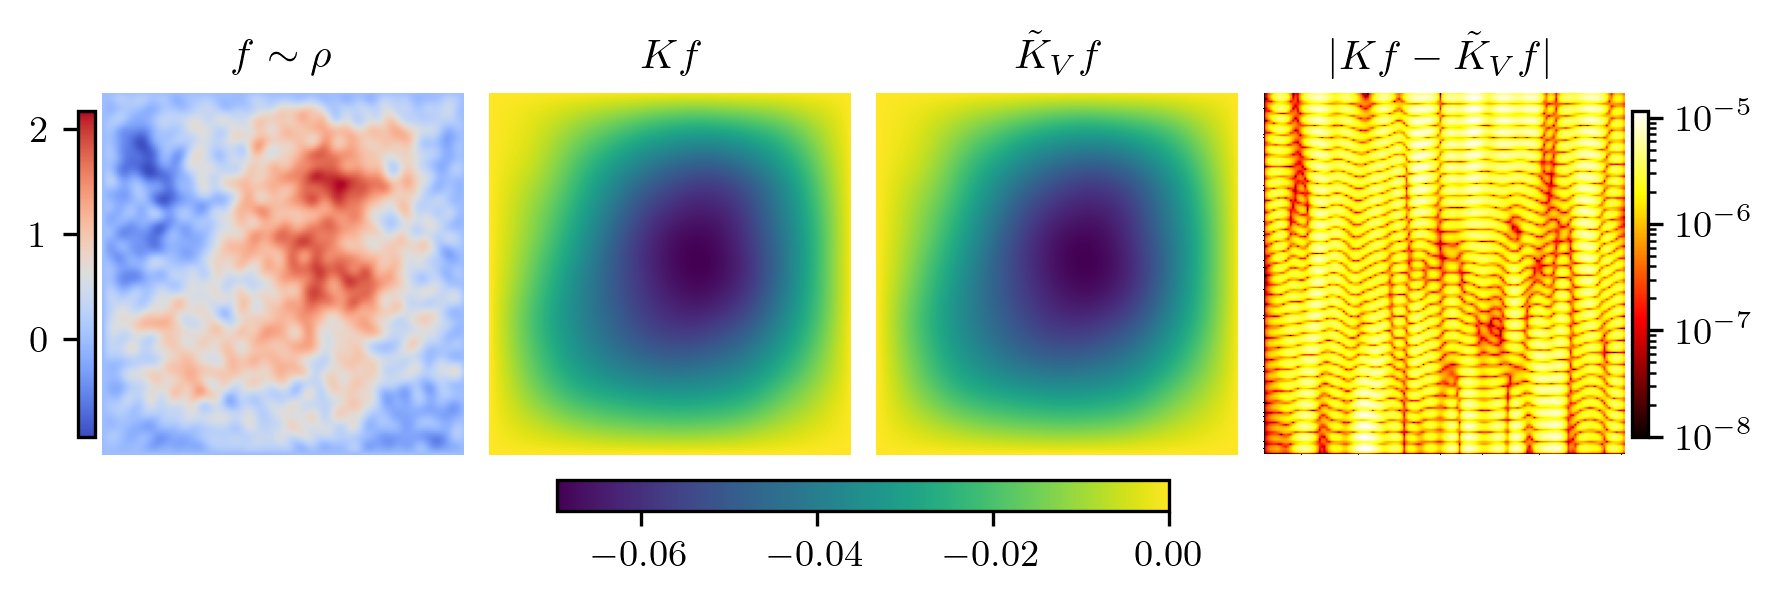

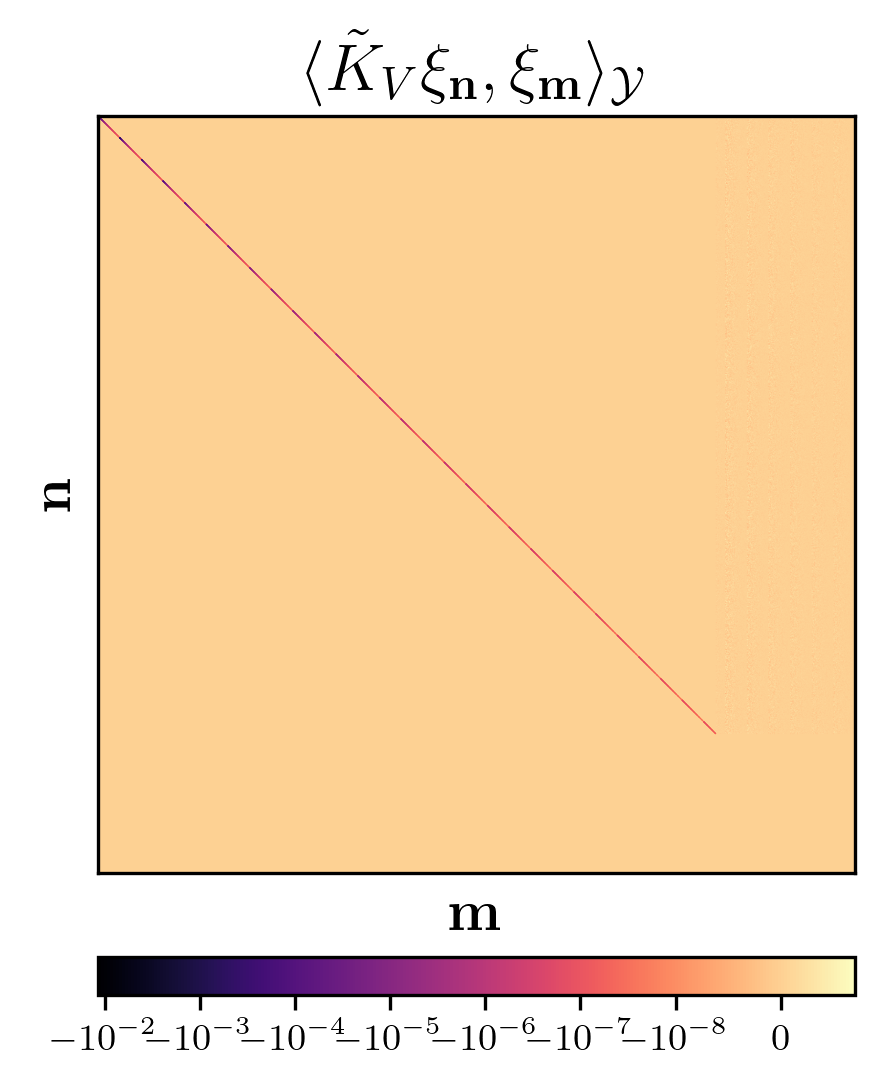

In [102]:
################################################################################################################
#                           Plot Errors and Representative Samples
################################################################################################################

import matplotlib as mpl
import matplotlib.pyplot as plt
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 1.0
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.6                     
# Font sizes
base = 9  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base + 1      
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base         
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 4
linewidth_large = 1 

import matplotlib.colors as colors 
import seaborn as sns

#--- Compute L2 error in output 
test_errors = np.linalg.norm(test_approx_outputs - test_output_samples, axis = 1)
train_errors = np.linalg.norm(approx_outputs - output_samples, axis = 1)
boch_norm_err = np.sqrt(np.mean(test_errors**2))

#--- Plot Error Distribution: 
# plt.hist(test_errors, bins = int(M_test/5), density = True, color = 'black', alpha = 0.1)
# sns.kdeplot(test_errors, fill = True, color = 'k')
# plt.axvline(boch_norm_err, linestyle = 'dotted', color = 'red', linewidth = 2, label = r"$\sqrt{\mathbb{E}\Vert Kf - \tilde{K}_Vf\Vert_{\mathcal{Y}}^2} = $"+f"{boch_norm_err:.4e}")
# plt.legend()
# plt.xlabel(r" $L^2_{\mathcal{Y}}$")
# plt.title(r"Error Distribution for $M_{\mathrm{test}} = $"+f"{M_test} Samples " + r"$f^i\sim \rho$")
# plt.show()

#-- Plot median error test sample 
sample = np.argmin(np.abs(test_errors - np.median(test_errors)))

# Set grid resolution
N_grid = 150
x = np.linspace(0, 1, N_grid, endpoint=False)
y = np.linspace(0, 1, N_grid, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')  # shape (N_grid, N_grid)

# Build Vandermond Matrix 
V = np.zeros((N_grid * N_grid, max_univariate_mode**2))
index = 0
for k in range(1, max_univariate_mode + 1):
    for m in range(1, max_univariate_mode + 1):
        basis_fn = 2 * np.sin(k* np.pi * X) * np.sin(m * np.pi * Y)  # shape (N, N)
        V[:, index] = basis_fn.flatten()
        index += 1


f_spatial = (V @ test_input_samples[sample]).reshape(N_grid,N_grid)
u_true = (V @ test_output_samples[sample]).reshape(N_grid,N_grid)
u_approx = (V @ test_approx_outputs[sample]).reshape(N_grid,N_grid)  
abs_error = np.abs(u_true - u_approx)

#from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, axes = plt.subplots(1, 4, figsize=(fig_width,1.3*fig_height), layout = 'constrained')

# --- Forcing Term (left colorbar) ---
im0 = axes[0].imshow(f_spatial, origin='lower', extent=[0, 1, 0, 1], cmap='coolwarm')
axes[0].set_title(r"$f\sim \rho$")
cbar0 = fig.colorbar(
    im0,
    ax=axes[0],
    location='left',
    fraction=0.05,
    pad=0.02,
)

# --- True & Approximate Solutions (shared color scale and colorbar) ---
vmin = min(u_true.min(), u_approx.min())
vmax = max(u_true.max(), u_approx.max())

im1 = axes[1].imshow(u_true, origin='lower', extent=[0, 1, 0, 1], cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(r"$Kf$")

im2 = axes[2].imshow(u_approx, origin='lower', extent=[0, 1, 0, 1], cmap='viridis', vmin=vmin, vmax=vmax)
axes[2].set_title(r"$\tilde{K}_Vf$")

# --- Absolute Error (right colorbar) ---
im3 = axes[3].imshow(abs_error, origin='lower', extent=[0, 1, 0, 1], norm = colors.LogNorm(abs_error.min()+1e-8, abs_error.max()),cmap='hot')
cbar3 = fig.colorbar(
    im3,
    ax=axes[3],
    location='right',
    fraction=0.05,
    pad=0.02
)
axes[3].set_title(r"$\vert Kf - \tilde{K}_Vf\vert $")

# Add shared colorbar under both solution plots
cbar_shared = fig.colorbar(im2, ax=axes, location='bottom', fraction = 0.025, pad=0.02)

for ax in axes:
    ax.axis('off')  # removes ticks, labels, and box frame
    ax.set_aspect('equal')

fig.canvas.draw()  # let constrained_layout compute positions
fig.set_constrained_layout(False)

axpos = axes[3].get_position()      # position of the right image axes
cpos = cbar3.ax.get_position()      # current position of the colorbar axes

# choose a bar height as a fraction of the axes height
h = axpos.height * 0.9              # e.g. 70% of the image height
# vertically center the bar relative to the image axes
y0 = axpos.y0 + (axpos.height - h) /2

# keep x and width from constrained_layout, adjust y and height
cbar3.ax.set_position([cpos.x0, y0, cpos.width, h])
cbar0.ax.set_position([cbar0.ax.get_position().x0, y0, cpos.width, h])

plt.savefig("Plots/median_err.pdf",bbox_inches = 'tight')

plt.show()



################################################################################################################
#                           Plot Approxiamte Operator 
################################################################################################################
opC = np.zeros((35**2,35**2))
opC[:n, :] = wls_operator.C

approx_op = opC      #shape (100,100)
fig,ax = plt.subplots(figsize = (fig_width,fig_height), layout = 'constrained')
im = ax.imshow(approx_op, norm = colors.SymLogNorm(vmin = opC.min(), vmax = opC.max(), linthresh=1e-8), cmap = 'magma')
ax.set_xlabel(r"$\mathbf{m}$", fontsize = 14)
ax.set_ylabel(r"$\mathbf{n}$",fontsize = 14),
ax.set(xticks = [], yticks = [])

ax.set_title(r"$\langle \tilde{K}_{V}\xi_\mathbf{n}, \xi_\mathbf{m}\rangle_{\mathcal{Y}}$", fontsize = 16)
fig.colorbar(im, 
             location = 'bottom',
             pad = 0.02,
             fraction = 0.05)
plt.savefig("Plots/approx_operator.pdf",bbox_inches = 'tight')
plt.show()